<img style="float:left" width="70%" src="pics/escudo_COLOR_1L_DCHA.png">
<img style="float:right" width="15%" src="pics/PythonLogo.svg">
<br style="clear:both;">


# *Practica 1 Wumpus*
### *Sistemas Inteligentes* (Curso 2024-2025)

## Docente

 - Pedro Latorre Carmona
 
## Autor
 - Arkaitz Diez Gonzalez
 


## IMPORTS

voy a importar todas las librerias y recursos necesarios para el correcto funcionamiento de mi codigo.

In [1]:
from copy import deepcopy, copy
from typing import Tuple, List
import random
import math
from IPython.display import display
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import threading
import os
from IPython.display import clear_output

import tkinter as tk
from PIL import ImageTk



## CLASE Tablerowumpus

Creacion de la clase Tablerowumpus con sus metodos para el uso del juego

In [2]:
class Tablerowumpus:
    # ****** INICIALIZACIÓN Y CONFIGURACIÓN ******
   
    def __init__(self, matrix):
        self.setMatrix(matrix)

    def setMatrix(self, matrix):
        self.matrix = deepcopy(matrix)
    
    def getMatrix(self) -> List[List]:
        return deepcopy(self.matrix)
    
    # ****** MÉTODOS DE COMPARACIÓN ******

    def __eq__(self, other) -> bool:
        alto = len(self.matrix)
        ancho = len(self.matrix[0])

        for i in range(ancho):
            for j in range(alto):
                if self.matrix[i][j] != other.matrix[i][j]:
                    return False
        return True
       
    
    # ****** INICIALIZAR JUEGO Y COLOCAR PERSONAJES ******

    def inicializar_juego(self):
        self.matrix[5][0] = 1  
        valores = [400, 200, 600, 700]  

        for valor in valores:
            while True:
                x = random.randint(0, 5)
                y = random.randint(0, 5)
                if self.matrix[x][y] == 0 and not (abs(x - 5) + abs(y - 0) == 1):
                    self.matrix[x][y] = valor
                    break

        return self.matrix

    def actualizar_vecinos(self):
        for x in range(6):
            for y in range(6):
                if self.matrix[x][y] == 200:  
                    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < 6 and 0 <= ny < 6:
                            if self.matrix[nx][ny] == 0:
                                self.matrix[nx][ny] = 300
                            elif self.matrix[nx][ny] == 500:
                                self.matrix[nx][ny] = 800
                elif self.matrix[x][y] in [600, 700]:  
                    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < 6 and 0 <= ny < 6:
                            if self.matrix[nx][ny] == 0:
                                self.matrix[nx][ny] = 500
                            elif self.matrix[nx][ny] == 300:
                                self.matrix[nx][ny] = 800
                                
    # ****** MOVIMIENTOS DISPONIBLES ******

    def canMoveUp(self, row: int, col: int) -> bool:
        return row > 0

    def canMoveDown(self, row: int, col: int) -> bool:
        return row < len(self.matrix) - 1

    def canMoveLeft(self, row: int, col: int) -> bool:
        return col > 0

    def canMoveRight(self, row: int, col: int) -> bool:
        return col < len(self.matrix) - 1
    
    def up(self, x: int, y: int):
    
        destino = self.matrix[x - 1][y]
        origen = self.matrix[x][y]

        if destino == 0 and origen == 1:
            # Intercambio de posiciones
            self.matrix[x][y], self.matrix[x - 1][y] = destino, origen

        elif origen == 1 and destino in [400, 200, 600, 700, 300, 500, 800]:
            # Combinar origen con destino
            self.matrix[x - 1][y] += origen
            self.matrix[x][y] = 0

        elif origen in [401, 201, 601, 701, 301, 501, 801] and destino == 0:
            # Mover agente al destino
            self.matrix[x - 1][y] = 1
            self.matrix[x][y] -= 1

        elif origen in [401, 201, 601, 701, 301, 501, 801] and destino in [400, 200, 600, 700, 300, 500, 800]:
            # Agregar agente al destino
            self.matrix[x - 1][y] += 1
            self.matrix[x][y] -= 1

    def down(self, x: int, y: int):
        # Movimiento hacia abajo
        destino = self.matrix[x + 1][y]
        origen = self.matrix[x][y]

        if destino == 0 and origen == 1:
            # Intercambio de posiciones
            self.matrix[x][y], self.matrix[x + 1][y] = destino, origen

        elif origen == 1 and destino in [400, 200, 600, 700, 300, 500, 800]:
            # Combinar origen con destino
            self.matrix[x + 1][y] += origen
            self.matrix[x][y] = 0

        elif origen in [401, 201, 601, 701, 301, 501, 801] and destino == 0:
            # Mover agente al destino
            self.matrix[x + 1][y] = 1
            self.matrix[x][y] -= 1

        elif origen in [401, 201, 601, 701, 301, 501, 801] and destino in [400, 200, 600, 700, 300, 500, 800]:
            # Agregar agente al destino
            self.matrix[x + 1][y] += 1
            self.matrix[x][y] -= 1


    def left(self, x: int, y: int):
        origen = self.matrix[x][y]
        destino = self.matrix[x][y - 1]

        # Verificar las condiciones y realizar acciones correspondientes
        if destino == 0:
            if origen == 1:
                # Intercambiar agente con una celda vacía
                self.matrix[x][y - 1], self.matrix[x][y] = origen, destino
            elif origen in [401, 201, 601, 701, 301, 501, 801]:
                # Mover agente especial a una celda vacía
                self.matrix[x][y - 1] = 1
                self.matrix[x][y] -= 1

        elif destino in [400, 200, 600, 700, 300, 500, 800]:
            if origen == 1:
                # Combinar agente con un destino específico
                self.matrix[x][y - 1] += origen
                self.matrix[x][y] = 0
            elif origen in [401, 201, 601, 701, 301, 501, 801]:
                # Mover agente especial a un destino ocupado
                self.matrix[x][y - 1] += 1
                self.matrix[x][y] -= 1

    def right(self, x: int, y: int):
        origen = self.matrix[x][y]
        destino = self.matrix[x][y + 1]

        # Caso: Agente se mueve a una celda vacía
        if destino == 0:
            if origen == 1:
                # Mover agente a una celda vacía
                self.matrix[x][y + 1], self.matrix[x][y] = origen, destino
            elif origen in [401, 201, 601, 701, 301, 501, 801]:
                # Mover agente especial (reduce el valor en origen)
                self.matrix[x][y + 1] = 1
                self.matrix[x][y] -= 1

        # Caso: Interacción con una celda ocupada
        elif destino in [400, 200, 600, 700, 300, 500, 800]:
            if origen == 1:
                # Agente combina con el destino
                self.matrix[x][y + 1] += origen
                self.matrix[x][y] = 0
            elif origen in [401, 201, 601, 701, 301, 501, 801]:
                # Agente especial combina con el destino
                self.matrix[x][y + 1] += 1
                self.matrix[x][y] -= 1

 # ****** MOVIMIENTOS POSIBLES PARA MAX Y MIN ******

    def getAvailableMovesForMax(self, row: int, col: int) -> List[int]:
        moves = []
        if self.canMoveUp(row, col):
            moves.append(1)
        if self.canMoveRight(row, col):
            moves.append(2)
        if self.canMoveDown(row, col):
            moves.append(3)
        if self.canMoveLeft(row, col):
            moves.append(4)
        return moves

    def getAvailableMovesForMin(self, tipo) -> List[Tuple[int]]:
        places = []
        altoMax, anchoMax = len(self.matrix), len(self.matrix[0])

        # Direcciones posibles: (dx, dy)
        direcciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]

        for i, fila in enumerate(self.matrix):
            for j, valor in enumerate(fila):
                if valor == tipo:
                    # Verificar todas las direcciones posibles
                    for dx, dy in direcciones:
                        nx, ny = i + dx, j + dy
                        if 0 <= nx < altoMax and 0 <= ny < anchoMax:
                            if self.matrix[nx][ny] in (0, 300, 500, 800):
                                places.append((nx, ny))

        return places


    # ****** EVALUACIÓN DEL ESTADO Y CÁLCULO DE UTILIDAD ******
    def encontrar_posiciones(self):
        # Identificar la ubicación del agente y del oro en la matriz
        pos_agente = None
        pos_oro = None

        for fila in range(6):
            for columna in range(6):
                # Verificar la posición del oro
                if self.matrix[fila][columna] in [400, 401]:
                    pos_oro = (fila, columna)
                # Verificar la posición del agente
                if self.matrix[fila][columna] in [1, 201, 301, 401, 501, 601, 701, 801]:
                    pos_agente = (fila, columna)

        return pos_agente, pos_oro

    def calcular_proximidad(self, pos_agente, pos_oro):
        # Calcular la cercanía entre el agente y el oro
        if pos_agente and pos_oro:
            dx = abs(pos_agente[1] - pos_oro[1])
            dy = abs(pos_agente[0] - pos_oro[0])
            return 1 / (dx + dy + 0.1)
        return 0

    def ajustar_puntaje(self, puntaje_inicial):
        # Modificar la puntuación según los elementos en la matriz
        puntaje = puntaje_inicial

        for fila in range(6):
            for columna in range(6):
                valor = self.matrix[fila][columna]
                # Ajustar puntaje según el elemento
                if valor == 201:  
                    puntaje -= 140
                elif valor in [601, 701]:  
                    puntaje -= 70
                elif valor in [301, 501, 801]:  
                    puntaje -= 25
                elif valor == 401:  
                    puntaje += 180

        return max(puntaje, 1)

    def utility(self):
        # Obtener las posiciones del agente y el oro
        agente, oro = self.encontrar_posiciones()
        # Calcular la proximidad
        cercania = self.calcular_proximidad(agente, oro)
        # Puntaje inicial basado en la proximidad
        puntaje_base = cercania * 110
        # Ajustar el puntaje final
        return self.ajustar_puntaje(puntaje_base)

    # ****** ACCIÓN DEL JUGADOR 1: MOVIMIENTO DE CUEVAS ******

    def movimientos_disponibles_cueva(self, tipo: int):
        # Retorna las posiciones adyacentes disponibles para mover una cueva
        posibles = []
        for fila in range(6):
            for col in range(6):
                if self.matrix[fila][col] == tipo:
                    if fila > 0 and self.matrix[fila - 1][col] in [0, 300, 500, 800]:
                        posibles.append((fila - 1, col))
                    if fila < 5 and self.matrix[fila + 1][col] in [0, 300, 500, 800]:
                        posibles.append((fila + 1, col))
                    if col > 0 and self.matrix[fila][col - 1] in [0, 300, 500, 800]:
                        posibles.append((fila, col - 1))
                    if col < 5 and self.matrix[fila][col + 1] in [0, 300, 500, 800]:
                        posibles.append((fila, col + 1))
        return posibles

    def mover_cueva_aleatoria(self):
        # Selección aleatoria del tipo de cueva (600 o 700)
        tipo_cueva = random.choice([600, 700])
        pos_cueva = None

        # Buscar la posición de la cueva en la matriz
        for fila in range(6):
            for col in range(6):
                if self.matrix[fila][col] == tipo_cueva:
                    pos_cueva = (fila, col)
                    break
            if pos_cueva:
                break

        # Obtener los movimientos posibles para la cueva
        movimientos = self.movimientos_disponibles_cueva(tipo_cueva)

        # Crear una copia del tablero para actualizar
        nuevo_tablero = deepcopy(self)

        if movimientos:
            # Escoger el primer movimiento disponible
            nueva_fila, nueva_col = movimientos[0]
            fila_c, col_c = pos_cueva

            # Mover la cueva a la nueva posición según el movimiento
            if nueva_fila == fila_c - 1:
                nuevo_tablero.matrix[fila_c][col_c] = 0
                nuevo_tablero.matrix[nueva_fila][col_c] = tipo_cueva

            elif nueva_fila == fila_c + 1:
                nuevo_tablero.matrix[fila_c][col_c] = 0
                nuevo_tablero.matrix[nueva_fila][col_c] = tipo_cueva

            elif nueva_col == col_c - 1:
                nuevo_tablero.matrix[fila_c][col_c] = 0
                nuevo_tablero.matrix[fila_c][nueva_col] = tipo_cueva

            elif nueva_col == col_c + 1:
                nuevo_tablero.matrix[fila_c][col_c] = 0
                nuevo_tablero.matrix[fila_c][nueva_col] = tipo_cueva

            # Actualizar vecinos después del movimiento
            nuevo_tablero.eliminar_vecinos()
            nuevo_tablero.actualizar_vecinos()

        return nuevo_tablero

    def eliminar_vecinos(self):
        # Limpiar casillas marcadas como contiguas (300, 500, 800)
        for x in range(6):
            for y in range(6):
                if self.matrix[x][y] in [300, 500, 800]:
                    self.matrix[x][y] = 0

        return self.matrix

    # ****** ACCIÓN DEL JUGADOR 2: DISPARO DEL AGENTE ******

    def disparo_al_azar(self):
        # Encontrar la posición del agente
        fila_agente, col_agente = -1, -1
        for r in range(6):
            for c in range(6):
                if self.matrix[r][c] in {1, 401, 201, 601, 701, 301, 501, 801}:
                    fila_agente, col_agente = r, c
                    break
            if fila_agente != -1:
                break

        # Escoger una dirección aleatoria (0: arriba, 1: derecha, 2: abajo, 3: izquierda)
        direccion = random.randrange(4)
        disparos = []
        x, y = fila_agente, col_agente

        # Función auxiliar para procesar el disparo en la dirección elegida
        def procesar_disparo(dx, dy):
            nonlocal x, y
            while 0 <= x + dx < 6 and 0 <= y + dy < 6:
                x += dx
                y += dy
                nuevo_estado = deepcopy(self)
                nuevo_estado.matrix[x][y] += 2
                disparos.append(nuevo_estado)

        # Determinar desplazamiento según la dirección
        if direccion == 0:  # Arriba
            procesar_disparo(-1, 0)
        elif direccion == 1:  # Derecha
            procesar_disparo(0, 1)
        elif direccion == 2:  # Abajo
            procesar_disparo(1, 0)
        elif direccion == 3:  # Izquierda
            procesar_disparo(0, -1)

        return disparos


    # ****** DETECCIÓN DE FIN DEL JUEGO (GAME OVER) ******

    def isGameOver(self) -> bool:
        for fila in self.matrix:
            for val in fila:
                # Verificar condiciones de fin de juego
                if val in [201, 401, 601, 701]:
                    return True
        return False


## Metodo MINIMAX

In [3]:
def miniMax(state: 'Tablerowumpus', currentLevel: int, maxLevel: int, player: int, alpha: int, beta: int, stop: bool) -> Tuple['Tablerowumpus', int, bool]:
    """
    Algoritmo Minimax con poda alfa-beta para evaluar el estado del juego.

    """

    matriz = state.getMatrix()

    # ****** GENERAR SUCESORES PARA MAX (Jugador 2) ******
    successorMatrices = []
    if player == 2:
        posAJ = None
        # Buscar la posición del agente (MAX)
        for i in range(6):
            for j in range(6):
                if matriz[i][j] in [1, 21, 31, 41, 51, 61, 71, 81]:
                    posAJ = [i, j]
                    break

        # Si se encontró la posición del agente, generar movimientos posibles
        if posAJ is not None:
            availableMoves = state.getAvailableMovesForMax(posAJ[0], posAJ[1])
            # Crear tableros sucesores aplicando cada movimiento posible
            for move in availableMoves:
                successorBoard = deepcopy(state)  # Crear copia del estado actual
                if move == 1:  # Mover arriba
                    successorBoard.up(posAJ[0], posAJ[1])
                elif move == 2:  # Mover derecha
                    successorBoard.right(posAJ[0], posAJ[1])
                elif move == 3:  # Mover abajo
                    successorBoard.down(posAJ[0], posAJ[1])
                elif move == 4:  # Mover izquierda
                    successorBoard.left(posAJ[0], posAJ[1])
                successorMatrices.append(successorBoard)

    # ****** GENERAR SUCESORES PARA MIN (Jugador 1) ******
    elif player == 1:
        CuevaMove = random.choice([600, 700])  # Seleccionar un tipo de cueva aleatorio (600 o 700)
        filaCueva, colCueva = None, None
        # Buscar la posición de la cueva
        for i in range(6):
            for j in range(6):
                if matriz[i][j] == CuevaMove:
                    filaCueva, colCueva = i, j
                    break

        # Generar movimientos posibles si se encontró la cueva
        if filaCueva is not None and colCueva is not None:
            availableMoves = state.getAvailableMovesForMin(CuevaMove)
            for fil, col in availableMoves:
                successorBoard = deepcopy(state)
                # Mover la cueva a la nueva posición
                if fil == filaCueva - 1 and col == colCueva:  # Mover arriba
                    successorBoard.matrix[filaCueva][colCueva] = 0
                    successorBoard.matrix[filaCueva - 1][colCueva] = CuevaMove
                elif fil == filaCueva + 1 and col == colCueva:  # Mover abajo
                    successorBoard.matrix[filaCueva][colCueva] = 0
                    successorBoard.matrix[filaCueva + 1][colCueva] = CuevaMove
                elif fil == filaCueva and col == colCueva - 1:  # Mover izquierda
                    successorBoard.matrix[filaCueva][colCueva] = 0
                    successorBoard.matrix[filaCueva][colCueva - 1] = CuevaMove
                elif fil == filaCueva and col == colCueva + 1:  # Mover derecha
                    successorBoard.matrix[filaCueva][colCueva] = 0
                    successorBoard.matrix[filaCueva][colCueva + 1] = CuevaMove
                successorBoard.eliminar_vecinos()
                successorBoard.actualizar_vecinos()
                successorMatrices.append(successorBoard)

    # ****** CASO BASE: Nivel máximo alcanzado o no hay sucesores ******
    if currentLevel == maxLevel or len(successorMatrices) == 0:
        return state, state.utility(), stop

    # ****** EVALUACIÓN DE SUCESORES PARA MAX (Jugador 2) ******
    bestMatrix = None
    if player == 2:
        maxValue = float('-inf')
        for successor in successorMatrices:
            _, utility, stop = miniMax(successor, currentLevel + 1, maxLevel, 1, alpha, beta, stop)
            # Actualizar el mejor valor para MAX
            if utility > maxValue:
                maxValue = utility
                bestMatrix = successor
            # Actualizar alfa y verificar poda
            alpha = max(alpha, utility)
            if utility >= beta:
                return bestMatrix, utility, stop
        return bestMatrix, maxValue, stop

    # ****** EVALUACIÓN DE SUCESORES PARA MIN (Jugador 1) ******
    else:
        minValue = float('inf')
        for successor in successorMatrices:
            _, utility, stop = miniMax(successor, currentLevel + 1, maxLevel, 2, alpha, beta, stop)
            # Actualizar el mejor valor para MIN
            if utility < minValue:
                minValue = utility
                bestMatrix = successor
            # Actualizar beta y verificar poda
            beta = min(beta, utility)
            if utility <= alpha:
                return bestMatrix, utility, stop
        return bestMatrix, minValue, stop



## metodo para usar minimax


In [4]:
def usarMinimax(tablero: Tablerowumpus, maxLevel: int) -> Tuple[Tablerowumpus, int, bool]:
         
    player = 2            
    alpha = -math.inf     
    beta = math.inf       
    stop = False 
    currentLevel = 0    
    itera = 0  
    
    bestMove, utility, stop = miniMax(tablero, currentLevel, maxLevel, player, alpha, beta, stop)
    
    return bestMove, utility, stop

## CONFIGURACION DE IMAGENES

In [5]:
image_paths = {
    "0": "./casillas_imagenes/casillavacia.webp",
    "1": "./casillas_imagenes/agente.webp",
    "2": "./casillas_imagenes/bala.webp",
    "200": "./casillas_imagenes/wumpus.webp",
    "202": "./casillas_imagenes/wumpusyagente.png",
    "300": "./casillas_imagenes/edor.webp",
    "400": "./casillas_imagenes/oro.webp",
    "500": "./casillas_imagenes/brisa.webp",
    "600": "./casillas_imagenes/agujero.webp",
    "700": "./casillas_imagenes/agujero.webp",
    "800": "./casillas_imagenes/brisayedor.png",
    "401": "./casillas_imagenes/oroyagente.png",
    "201": "./casillas_imagenes/wumpusyagente.png",
    "601": "./casillas_imagenes/agujeroyagente.png",
    "701": "./casillas_imagenes/agujeroyagente.png",
    "501": "./casillas_imagenes/agenteybrisa.png",
    "301": "./casillas_imagenes/agenteyedor.png",
    "801": "./casillas_imagenes/brisaedoryagente.png",
    "402": "./casillas_imagenes/balayoro.png",
    "602": "./casillas_imagenes/agujeroybala.png",
    "702": "./casillas_imagenes/agujeroybala.png",
    "502": "./casillas_imagenes/brisaybala.png",
    "302": "./casillas_imagenes/balayedor.png",
    "802": "./casillas_imagenes/balaedorybrisa.png",
}



def obtener_imagen(numero: int, tamaño: tuple = (50, 50)) -> np.ndarray:
    """
    Obtiene y redimensiona la imagen asociada a 'numero'. Si no se encuentra,
    devuelve una imagen negra del tamaño especificado.
    """
    img_path = image_paths.get(str(numero))

    if not img_path:
        print(f"[Aviso] Imagen no encontrada para el número: {numero}")
        return np.zeros((*tamaño, 3), dtype=np.uint8)

    try:
        with Image.open(img_path) as img:
            return np.array(img.resize(tamaño))
    except Exception as e:
        print(f"[Error] No se pudo cargar la imagen para el número {numero}: {e}")
        return np.zeros((*tamaño, 3), dtype=np.uint8)

def imprimir_tablero(matriz: 'Tablerowumpus', tamaño: tuple = (50, 50)) -> None:
    """
    Imprime el tablero usando imágenes para cada celda de la matriz.
    """
    fig, ax = plt.subplots(6, 6, figsize=(8, 8))
    fig.subplots_adjust(hspace=0.1, wspace=0.1)

    for i in range(6):
        for j in range(6):
            numero = matriz.matrix[i][j]
            imagen = obtener_imagen(numero, tamaño)
            ax[i, j].imshow(imagen)
            ax[i, j].axis('off')

    plt.show()

def mostrar_juego(estados: list) -> None:
    """
    Muestra la secuencia de estados del juego .
    """
    for estado in estados:
        imprimir_tablero(estado)
        clear_output(wait=True)

## Inicio del juego

Aquí se inicializa el tablero y se llaman los métodos y funciones para generar el tablero y jugar la partida.

PARA INICIAR JUEGO HACER RUN EN TODAS LAS CASILLAS Y ASEGURARSE QUE EL NOTEBOOK ESTA EN LA MISMA CARPETA QUE LA CARPETA DE IMAGENES

Turno del agente inteligente...
El Wumpus se mueve a otra cueva.
Turno del agente inteligente...
El Wumpus se mueve a otra cueva.
Turno del agente inteligente...
El Wumpus se mueve a otra cueva.
Turno del agente inteligente...
El agente realiza un disparo aleatorio...
El Wumpus se mueve a otra cueva.
Turno del agente inteligente...
El Wumpus se mueve a otra cueva.
Turno del agente inteligente...

¡El juego ha concluido exitosamente!
Felicidades, ¡has ganado la partida!

Fin del juego. Gracias por participar.
Autor: Arkaitz Díez González
Espero que hayas disfrutado del desafío. Revisa los estados para ver cómo se desarrolló la partida.

Mostrando la secuencia de estados alcanzados...


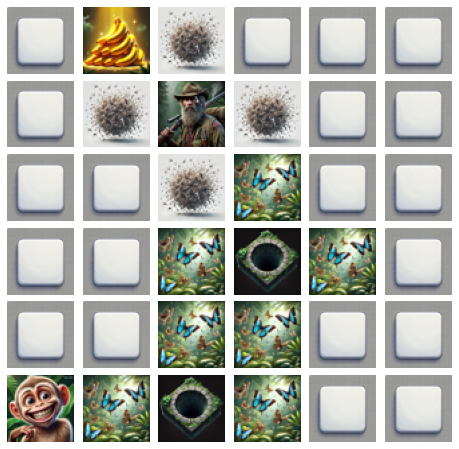

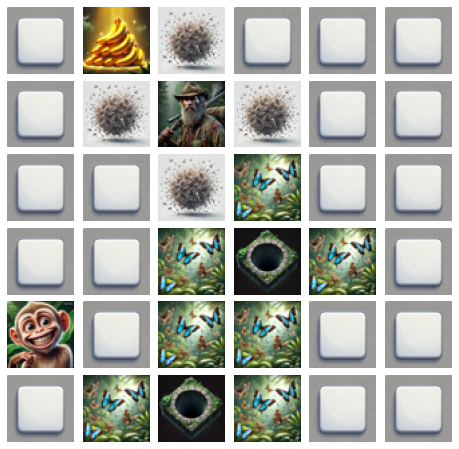

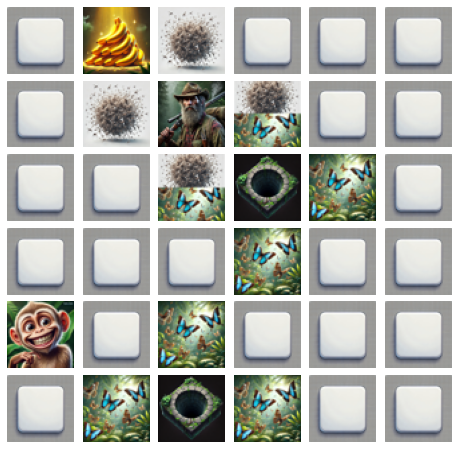

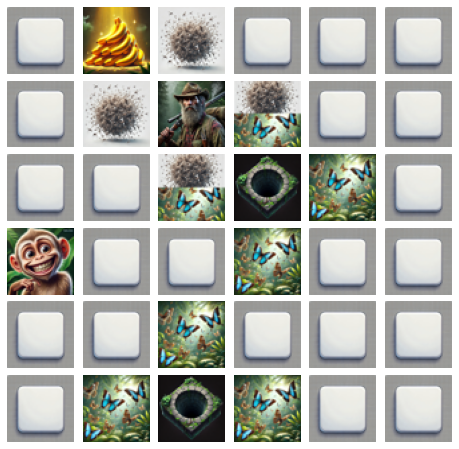

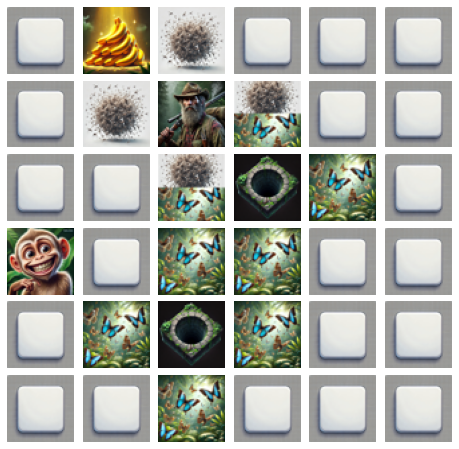

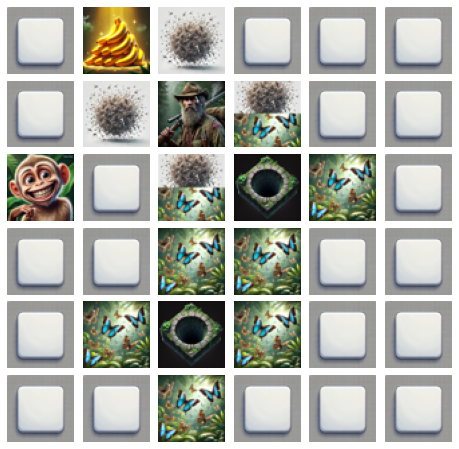

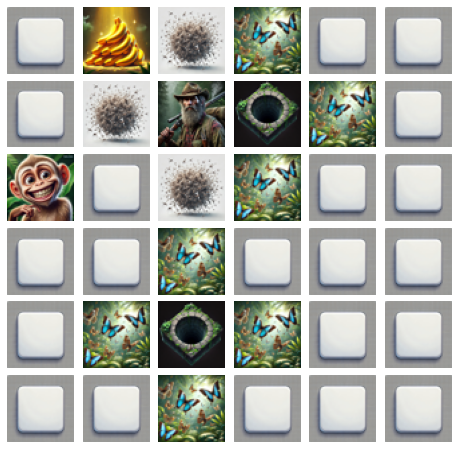

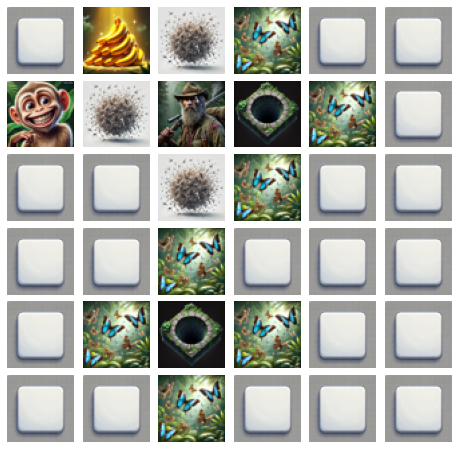

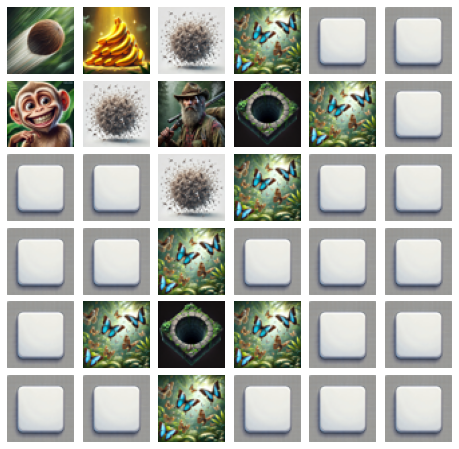

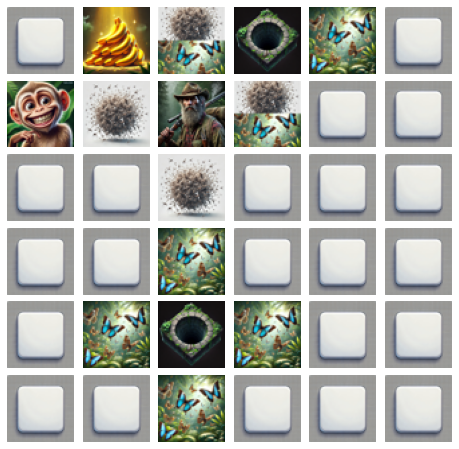

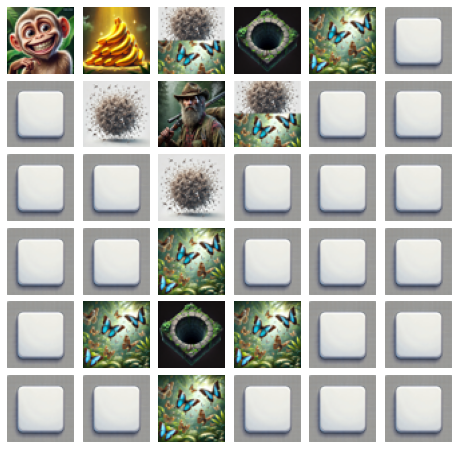

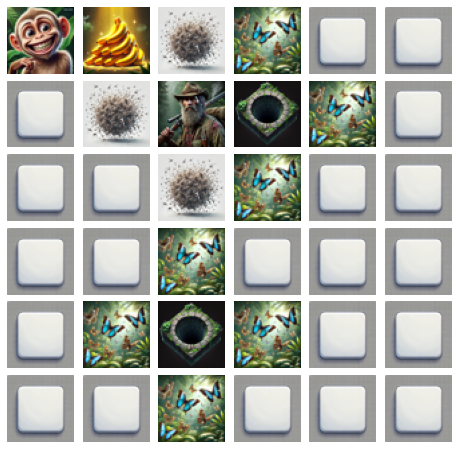

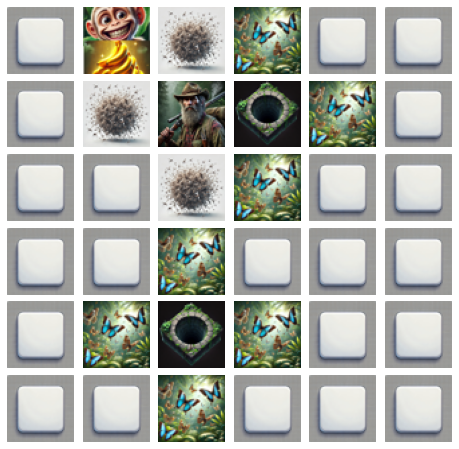

In [6]:

matriz_inicial = [
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0], 
]


# Lista para almacenar los estados del juego
historial_estados = []

# Mensaje de bienvenida
print("----- ¡Bienvenido al Mundo del Wumpus! -----")
print("Esta es la Práctica 1 de Sistemas Inteligentes.")
print("Desarrollado por Arkaitz Díez González")
print("\nIniciando el juego, por favor espera...")

# Variables de control del juego
juego_activo = True
contador_disparos = 0
wumpus_eliminado = False

# Creación del tablero inicial
tablero_inicial = Tablerowumpus(matriz_inicial)
tablero_inicial.inicializar_juego()
tablero_inicial.actualizar_vecinos()

print("\nTablero inicial generado aleatoriamente salvo agente:")
imprimir_tablero(tablero_inicial)

print("\nLa partida comenzará en unos instantes, ¡prepárate!")
threading.Event().wait(3)
clear_output(wait=True)

# Agregar el estado inicial al historial
historial_estados.append(deepcopy(tablero_inicial))
tablero_actual = tablero_inicial

# Bucle principal para ejecutar el juego
while juego_activo:
    print("Turno del agente inteligente...")
    siguiente_tablero, utilidad, detener = usarMinimax(tablero_actual, 2)
    historial_estados.append(deepcopy(siguiente_tablero))

    # Comprobar si el juego ha terminado
    if siguiente_tablero.isGameOver():
        juego_activo = False
        print("\n¡El juego ha concluido exitosamente!")
        print("Felicidades, ¡has ganado la partida!")
        break

    # Incrementar el contador de disparos
    contador_disparos += 1

    # Disparar al azar si se han realizado 4 movimientos
    if contador_disparos == 4:
        print("El agente realiza un disparo aleatorio...")
        tableros_tras_disparo = deepcopy(siguiente_tablero.disparo_al_azar())

        # Verificar si el Wumpus ha sido alcanzado
        for tablero in tableros_tras_disparo:
            historial_estados.append(deepcopy(tablero))
            if any(32 in fila for fila in tablero.matrix):
                print("¡El Wumpus ha sido eliminado!")
                wumpus_eliminado = True
                break

    # Continuar si el Wumpus sigue vivo
    if not wumpus_eliminado:
        print("El Wumpus se mueve a otra cueva.")
        tablero_siguiente = deepcopy(siguiente_tablero.mover_cueva_aleatoria())
        historial_estados.append(deepcopy(tablero_siguiente))
        tablero_actual = tablero_siguiente
    else:
        print("\nEl Wumpus ha sido derrotado.")
        print("Reproduciendo la partida completa...")
        break

# Mostrar la salida final del juego
print("\nFin del juego. Gracias por participar.")
print("Autor: Arkaitz Díez González")
print("Espero que hayas disfrutado del desafío. Revisa los estados para ver cómo se desarrolló la partida.")
print("\nMostrando la secuencia de estados alcanzados...")

# Imprimir todos los estados del juego
for estado in historial_estados:
    imprimir_tablero(estado)
